## Desafio DATA2: Ciência e Análise de Dados

Saneamento e Qualidade de Dados - Nur Mah Museum

Primeira etapa do desafio técnico diagnóstico da CODE[] Jr..

Limpeza, tratamento e preparação da base de dados do diretório de organizações culturais nos Estados Unidos.

Configuração do Ambiente e Carga dos Dados

Importação da biblioteca Pandas para manipulação de tabelas e carregamento do arquivo CSV aplicando o parâmetro

low_memory=False para garantir consistência na leitura dos tipos de dados.

In [9]:
import pandas as pd

In [10]:
# Base de dados
caminho_arquivo = r'E:\desafio-data2-code\dados\museums.csv'
df = pd.read_csv(caminho_arquivo, low_memory=False)

# Primeiras linhas da tabela
df.head()

,Museum ID,Museum Name,Legal Name,Alternate Name,Museum Type,Institution Name,Street Address (Administrative Location),City (Administrative Location),State (Administrative Location),Zip Code (Administrative Location),...,Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Employer ID Number,Tax Period,Income,Revenue
0,8400200098,ALASKA AVIATION HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,4721 AIRCRAFT DR,ANCHORAGE,AK,99502,...,61.17925,-149.97254,1.0,20.0,2.0,6,920071852,201312.0,602912.0,550236.0
1,8400200117,ALASKA BOTANICAL GARDEN,ALASKA BOTANICAL GARDEN INC,NaN,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",NaN,4601 CAMPBELL AIRSTRIP RD,ANCHORAGE,AK,99507,...,61.16890,-149.76708,4.0,20.0,2.0,6,920115504,201312.0,1379576.0,1323742.0
2,8400200153,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,NaN,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,NaN,9711 KENAI SPUR HWY,KENAI,AK,99611,...,60.56149,-151.21598,3.0,122.0,2.0,6,921761906,201312.0,740030.0,729080.0
3,8400200143,ALASKA EDUCATORS HISTORICAL SOCIETY,ALASKA EDUCATORS HISTORICAL SOCIETY,NaN,HISTORIC PRESERVATION,NaN,214 BIRCH STREET,KENAI,AK,99611,...,60.56280,-151.26597,3.0,122.0,2.0,6,920165178,201412.0,0.0,0.0
4,8400200027,ALASKA HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,301 W NORTHERN LIGHTS BLVD,ANCHORAGE,AK,99503,...,61.17925,-149.97254,1.0,20.0,2.0,6,920071852,201312.0,602912.0,550236.0


Entendendo o tamanho do problema:

Verificação da estrutura da tabela, quantidade de valores nulos por coluna e a existência de linhas duplicadas.

In [12]:
# Verificação das informações gerais e tipos de dados
print("Estrutura do DataFrame")
df.info()

# Valores nulos por coluna
print("\n Valores Nulos por Coluna")
valores_nulos = df.isnull().sum()
print(valores_nulos[valores_nulos > 0])

# linhas duplicadas
print("\n Linhas Duplicadas")
total_duplicados = df.duplicated().sum()
print(f"Total de registros idênticos repetidos: {total_duplicados}")

Estrutura do DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33072 entries, 0 to 33071
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Museum ID                                 33072 non-null  int64  
 1   Museum Name                               33072 non-null  object 
 2   Legal Name                                33072 non-null  object 
 3   Alternate Name                            1927 non-null   object 
 4   Museum Type                               33072 non-null  object 
 5   Institution Name                          2749 non-null   object 
 6   Street Address (Administrative Location)  33062 non-null  object 
 7   City (Administrative Location)            33072 non-null  object 
 8   State (Administrative Location)           33072 non-null  object 
 9   Zip Code (Administrative Location)        33072 non-null  object 
 10  Street Addr

**Remoção de Registros Duplicados**

Como uma organização cultural não deve aparecer de forma idêntica duas vezes no diretório,

removemos as cópias exatas mantendo apenas a primeira ocorrência.

Obs: Neste caso específico não houve registros duplicados, mas mantive o código para remoção para caso no futuro haja algum.

In [14]:
# Remoção linhas duplicadas
df_limpo = df.drop_duplicates()

print(f"Linhas antes: {df.shape[0]} | Linhas depois: {df_limpo.shape[0]}")

Linhas antes: 33072 | Linhas depois: 33072


**Tratamento de Valores Nulos na Variável (Revenue)**

A coluna de Receita (Revenue) possui milhares de campos vazios.
Substituir esses valores pela Média seria um erro, pois o mercado de museus possui poucos representantes bilionários
que puxariam a média para cima de forma artificial, trazendo assim dados falsos ou muito longe da realidade. 

Por conta disso, utilizei a Mediana por categoria de museu (Museum Type) 
para preencher as lacunas de forma estatisticamente correta e representativa para o negócio.

In [17]:
# Calculo da mediana de receita para cada tipo de museu
medianas_por_tipo = df_limpo.groupby('Museum Type')['Revenue'].transform('median')

# Preenchimento dos campos vazios da coluna Revenue com as respectivas medianas
df_limpo['Revenue'] = df_limpo['Revenue'].fillna(medianas_por_tipo)

# Verificação se ainda restou algum valor nulo na receita
print(f"Valores nulos restantes em Revenue: {df_limpo['Revenue'].isnull().sum()}")

Valores nulos restantes em Revenue: 0


**Saneamento Inicial Concluído!**

A base agora está livre de registros duplicados e a nossa principal variável financeira foi tratada usando critérios estatísticos.

**Pergunta 1: Qual é a distribuição financeira (receita) entre os diferentes tipos de museus (Arte, Ciência, Zoos, História)?**

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Análise numérica por tipo de museu (Quantidade, média, mediana e valor máximo)
print("Resumo Financeiro por Tipo de Museu")
resumo_financeiro = df_limpo.groupby('Museum Type')['Revenue'].describe()
print(resumo_financeiro[['count', 'mean', '50%', 'max']])

Resumo Financeiro por Tipo de Museu
                                                 count          mean  \
Museum Type                                                            
ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER   1484.0  3.901468e+07   
ART MUSEUM                                      3241.0  5.799220e+07   
CHILDREN'S MUSEUM                                512.0  9.714871e+05   
GENERAL MUSEUM                                  8699.0  1.270549e+07   
HISTORIC PRESERVATION                          14861.0  1.696038e+06   
HISTORY MUSEUM                                  2284.0  8.356335e+06   
NATURAL HISTORY MUSEUM                           346.0  5.810606e+07   
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM      1081.0  4.377394e+07   
ZOO, AQUARIUM, OR WILDLIFE CONSERVATION          564.0  2.997986e+06   

                                                     50%           max  
Museum Type                                                             
ARBORETUM, BOTANICAL GARD

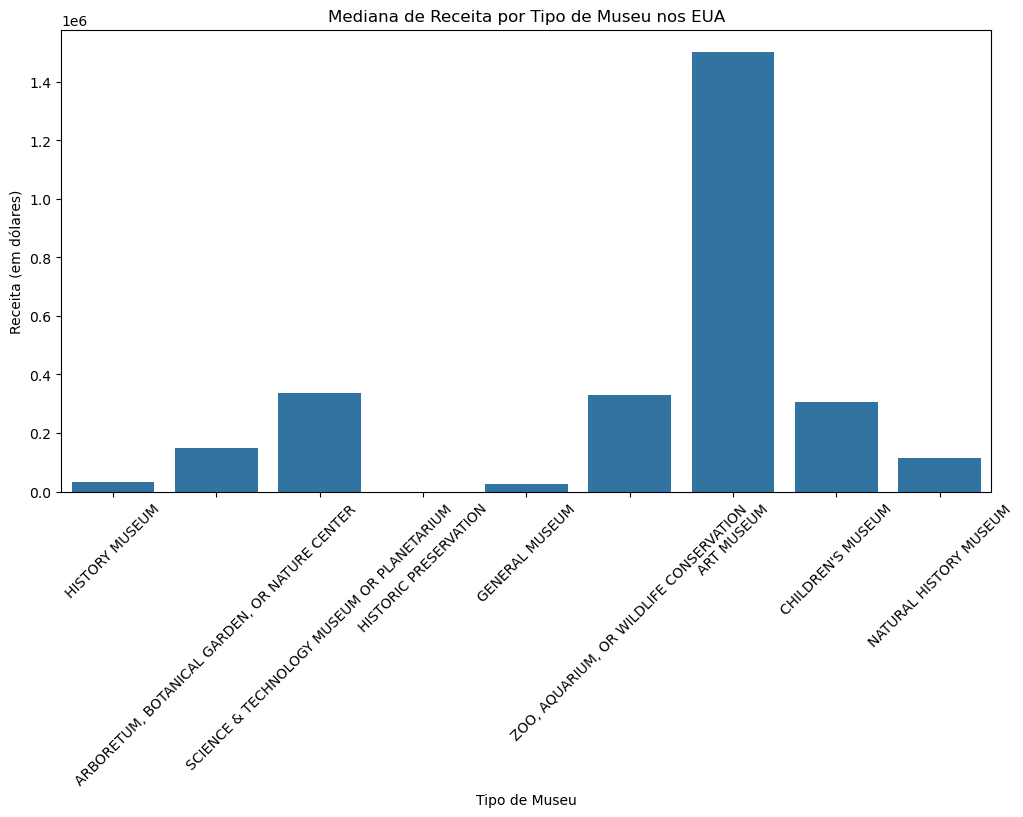

In [23]:
# Gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(data=df_limpo, x='Museum Type', y='Revenue', estimator='median', errorbar=None)

plt.title('Mediana de Receita por Tipo de Museu nos EUA')
plt.xlabel('Tipo de Museu')
plt.ylabel('Receita (em dólares)')
plt.xticks(rotation=45) # Inclinação dos nomes dos museus para não embolar e ficar melhor para visualização

plt.show()

**Pergunta 2: Como é que a composição de tipos de museus difere geograficamente?**

Top 5 Estados com mais Museus de Arte
State (Administrative Location)
CA    343
NY    248
TX    168
PA    159
FL    135
Name: count, dtype: int64


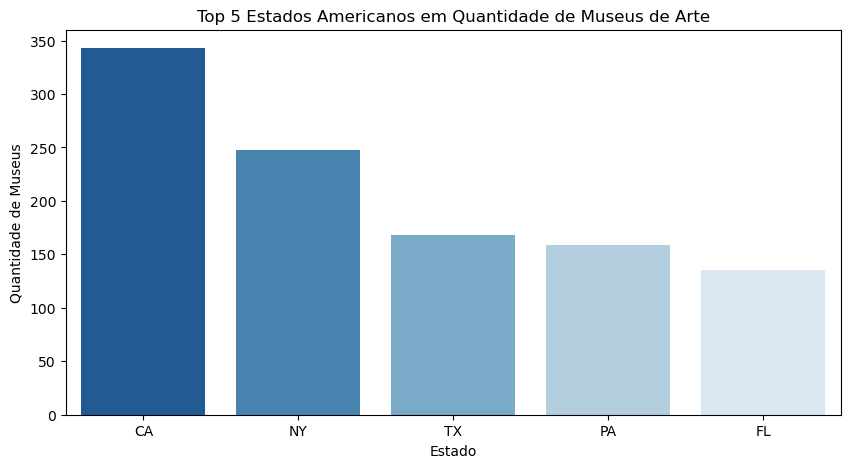

In [27]:
# Filtrando a tabela para olhar apenas museus de arte
df_arte = df_limpo[df_limpo['Museum Type'] == 'ART MUSEUM']

# Quantidade de museus de arte em cada Estado
top5_estados_arte = df_arte['State (Administrative Location)'].value_counts().head(5)

print("Top 5 Estados com mais Museus de Arte")
print(top5_estados_arte)

# Gráfico simples para mostrar Top 5
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top5_estados_arte.index, 
    y=top5_estados_arte.values, 
    hue=top5_estados_arte.index,  
    palette='Blues_r', 
    legend=False                
)

plt.title('Top 5 Estados Americanos em Quantidade de Museus de Arte')
plt.xlabel('Estado')
plt.ylabel('Quantidade de Museus')
plt.show()

O mercado de museus nos Estados Unidos se concentra em sua maioria nos estados da Califórnia e Nova York.
    
Então estes estados seriam ótimas oprtunidades para o Nur Mah Museum abrir mercado com um público muito grande e alta circulação de visitantes,

porém também seria onde o Nur Mah Museum encontraria a maior concorrência.

**Pergunta 3: Existem discrepâncias gritantes que distorçam o mercado?**

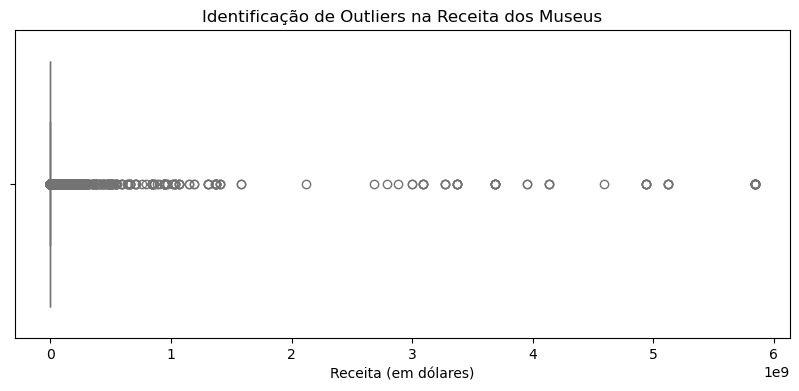

In [29]:
# Gráfico de caixa (Boxplot) para visualização da distribuição da Receita
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_limpo, x='Revenue', color='lightgreen')

plt.title('Identificação de Outliers na Receita dos Museus')
plt.xlabel('Receita (em dólares)')
plt.show()

**Resposta da Pergunta 3:**

Sim, existem discrepâncias (outliers) que distorcem completamente o mercado de museus nos Estados Unidos. 

Como podemos ver no gráfico de caixa (Boxplot):
1. A imensa maioria das instituições está concentrada bem perto do valor zero, indicando receitas baixas.
2. Há um longo rastro de pontos isolados à direita que se estende até a faixa de 6 bilhões de dólares ($6 \times 10^9$). Cada ponto desse representa um museu outlier (como grandes centros artísticos bilionários).

Esses poucos museus gigantes distorcem a realidade financeira do setor. Se utilizássemos a **Média** para analisar os dados, esses valores bilionários puxariam o resultado para cima, gerando uma falsa impressão de que os museus faturam mais do que faturam na realidade. Isso justifica a decisão de usar a **Mediana** no saneamento dos dados, já que a mediana ignora esses extremos e reflete a receita real da maioria das instituições.

**Recomendações Estratégicas para o Nur Mah Museum**

Com base nos três gráficos gerados na análise, apresento três recomendações para a diretoria executiva do museu tomar decisões:

* **Recomendação 1 (Baseada no Gráfico 1): Foco no Mercado de Médio Porte**
O primeiro gráfico mostrou que os Museus de Arte (ART MUSEUM) estão em um grupo intermediário, faturando bem mais que os museus de história, mas sem os custos bilionários de zoológicos. A diretoria deve planejar seus gastos e metas espelhando-se em outros museus de arte, ignorando a "média" geral do mercado, que é enganosa.

* **Recomendação 2 (Baseada no Gráfico 2): Estratégia de Localização e Concorrência**
A análise geográfica provou que a Califórnia e Nova York concentram a maior quantidade de museus de arte do país. Se o Nur Mah Museum quiser abrir mercado onde estão os maiores doadores e o maior público, esses são os estados certos. Porém, a diretoria deve criar um diferencial, pois a concorrência nessas duas regiões é a maior dos EUA.

* **Recomendação 3 (Baseada no Gráfico 3): Planejamento Orçamentário Baseado na Mediana**
O gráfico de caixa provou que o mercado é distorcido por pouquíssimos museus que ganham bilhões de dólares (outliers). Por isso, qualquer projeção de quanto dinheiro o Nur Mah Museum espera arrecadar no futuro deve usar a **Mediana** do setor como base, e nunca a Média. Isso protegerá o museu de criar expectativas financeiras falsas e perigosas.